In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [1]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity



import os
import glob
import json
import numpy as np
import tensorflow as tf
import sys

In [2]:
import sys
fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'
if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)


In [3]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample']

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn
import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN

from new_datasets_generation import splitting_and_dataset_elaboration

timepoints_elaboration rimosso dalla cache
results_elaboration non trovato nella cache
new_datasets_generation non trovato nella cache
old_cellCnn.model non trovato nella cache
old_cellCnn.utils non trovato nella cache
old_cellCnn.downsample non trovato nella cache


# Import datasets from .csv

In [4]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

Elaborating file 0: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220204-2900.csv
Elaborating file 1: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220208-3665.csv
Elaborating file 2: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220216-3546.csv
Elaborating file 3: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 4: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 5: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 6: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 7: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 8: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
Elaborating

# Elaborate datasets

In [5]:
for i, dataset in enumerate(ALL_DATASETS):
    blast_n = (dataset['IsBlast'] == 1).sum()
    
    print(f'dataset {i} has {blast_n} cells over {len(dataset)} cells')

dataset 0 has 0 cells over 6558750 cells
dataset 1 has 0 cells over 2764877 cells
dataset 2 has 0 cells over 1291729 cells
dataset 3 has 1348 cells over 843500 cells
dataset 4 has 170 cells over 1404000 cells
dataset 5 has 0 cells over 3265250 cells
dataset 6 has 639 cells over 430869 cells
dataset 7 has 15 cells over 722000 cells
dataset 8 has 757 cells over 864000 cells
dataset 9 has 0 cells over 1947518 cells
dataset 10 has 308059 cells over 778750 cells
dataset 11 has 830101 cells over 5510750 cells
dataset 12 has 72 cells over 208000 cells
dataset 13 has 0 cells over 2912500 cells
dataset 14 has 3096 cells over 160500 cells
dataset 15 has 1449 cells over 3591480 cells
dataset 16 has 0 cells over 3107000 cells
dataset 17 has 9147 cells over 637409 cells
dataset 18 has 227 cells over 2928000 cells
dataset 19 has 518 cells over 164553 cells
dataset 20 has 398 cells over 191975 cells
dataset 21 has 0 cells over 169000 cells
dataset 22 has 2390 cells over 479000 cells
dataset 23 has 77

In [6]:
# Show patients donations
print(multiple_donations)

{'11': [3, 4, 5], '12': [6, 7], '1': [8, 9], '2': [10, 11], '3': [12, 13], '4': [14, 15, 16], '6': [17, 18], '7': [19, 20, 21], '8': [22, 23], '9': [24, 25], '13': [0], '14': [1], '15': [2]}


In [7]:
healthy_donors, blast_donors, mixed_donors = donor_division(multiple_donations, ALL_DATASETS)

print(healthy_donors, blast_donors, mixed_donors)

{'11': [1, 1, 0], '12': [1, 1], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1], '13': [0], '14': [0], '15': [0]}
['12', '2', '6', '8', '9'] ['13', '14', '15'] ['11', '1', '3', '4', '7']


In [8]:

# Samples donors for Train, Validation and Test sets    
train_donors_idx, val_donors_idx, test_donors_idx = dataset_elaboration(multiple_donations, ALL_DATASETS, healthy_donors, blast_donors,
                        mixed_donors, seed = 42)



Precess starts. Dividing donors...
healthy_donors_idx, blast_donors_idx, mixed_donors_idx: [0, 4, 2, 1, 3], [0, 2, 1],[4, 0, 2, 1, 3]
Seting Train, Validation and Test idx...
['12', '9', '13', '7', '11'] ['6', '15', '3'] ['2', '8', '14', '1', '4']


In [9]:

#  Retrieves specific donor datasets from all datasets list
train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
test_datasets_extracted = donation_extraction(test_donors_idx, multiple_donations, ALL_DATASETS)


print(len(train_datasets_extracted)) # list of donators
print(len(train_datasets_extracted[0])) # list of donations
print(len(test_datasets_extracted[0][0])) # dataset of cells

5
2
778750


In [10]:
n_sub = 3
seed = 42
n_cells = 100000
new_train_datasets, new_train_y, new_val_datasets, new_val_y, new_test_datasets, new_test_y = splitting_and_dataset_elaboration(train_datasets_extracted, 
                                                                                    val_datasets_extracted, test_datasets_extracted,
                                                                                    n_sub, n_cells, seed)



New training datasets creation...
5
2

New Donor
2
Tot blast data in the donor timepoints: 639
Tot blast data in the donor timepoints: 654
Extraction Done
Condition: 1

New Donor
2
Tot blast data in the donor timepoints: 44697
Tot blast data in the donor timepoints: 46110
Extraction Done
Condition: 1

New Donor
1
Timepoint condition: Healthy
Extraction Done
Condition: 0

New Donor
3
Tot blast data in the donor timepoints: 518
Tot blast data in the donor timepoints: 916
Tot blast data in the donor timepoints: 916
Extraction Done
Condition: 1

New Donor
3
Tot blast data in the donor timepoints: 1348
Tot blast data in the donor timepoints: 1518
Tot blast data in the donor timepoints: 1518
Extraction Done
Condition: 1
[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0]
Done!

New training datasets creation...

New Donor
Tot blast data in the donor timepoints: 9147
Tot blast data in the donor timepoints: 9374
Extraction Done
Condition: 1

New Donor
Timepoint co

In [11]:
for i, dataset in enumerate(new_test_datasets):
    blast_n = (dataset['IsBlast'] == 1).sum()
    
    print(f'dataset {i} has {blast_n} cells over {len(dataset)} cells. Label: {new_test_y[i]}')

dataset 0 has 500 cells over 100000 cells. Label: 1
dataset 1 has 1000 cells over 100000 cells. Label: 1
dataset 2 has 1000 cells over 100000 cells. Label: 1
dataset 3 has 0 cells over 100000 cells. Label: 0
dataset 4 has 0 cells over 100000 cells. Label: 0
dataset 5 has 0 cells over 100000 cells. Label: 0
dataset 6 has 500 cells over 100000 cells. Label: 1
dataset 7 has 5000 cells over 100000 cells. Label: 1
dataset 8 has 5000 cells over 100000 cells. Label: 1
dataset 9 has 0 cells over 100000 cells. Label: 0
dataset 10 has 0 cells over 100000 cells. Label: 0
dataset 11 has 0 cells over 100000 cells. Label: 0
dataset 12 has 0 cells over 100000 cells. Label: 0
dataset 13 has 0 cells over 100000 cells. Label: 0
dataset 14 has 0 cells over 100000 cells. Label: 0
dataset 15 has 500 cells over 100000 cells. Label: 1
dataset 16 has 1000 cells over 100000 cells. Label: 1
dataset 17 has 5000 cells over 100000 cells. Label: 1
dataset 18 has 0 cells over 100000 cells. Label: 0
dataset 19 has 0 

In [12]:
print(len(new_train_datasets))
print(len(new_train_y))
print(len(new_val_datasets))
print(len(new_val_y))
print(len(new_test_datasets))
print(len(new_test_y))


27
27
15
15
27
27


In [13]:
original_test_datasets = []
original_test_y = []
for donor in test_datasets_extracted:
    for dataset in donor:

        if len(dataset[dataset['IsBlast'] == 1]) > 0:
            original_test_y.append(1)

        else:
            original_test_y.append(0)
        dataset = dataset.drop(columns = ['IsBlast'])
        original_test_datasets.append(dataset)
print(len(original_test_datasets))
print(original_test_y)

10
[1, 1, 1, 1, 0, 1, 0, 1, 1, 0]


In [14]:
new_no_label_test_datasets = []
for dataset in new_test_datasets:
    dataset = dataset.drop(columns = ['IsBlast'])
    
    new_no_label_test_datasets.append(dataset)
print(len(new_no_label_test_datasets))

27


In [15]:
'''
def remove_isblast(datasets_list):
    new_train = []
    for dataset in datasets_list:
        new_train.append(dataset.drop(columns = ['IsBlast']))
    return new_train


new_val_datasets = remove_isblast(new_val_datasets)
new_train_datasets = remove_isblast(new_train_datasets)
new_test_datasets = remove_isblast(new_test_datasets)
'''

"\ndef remove_isblast(datasets_list):\n    new_train = []\n    for dataset in datasets_list:\n        new_train.append(dataset.drop(columns = ['IsBlast']))\n    return new_train\n\n\nnew_val_datasets = remove_isblast(new_val_datasets)\nnew_train_datasets = remove_isblast(new_train_datasets)\nnew_test_datasets = remove_isblast(new_test_datasets)\n"

In [16]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample']

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn
import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN

from new_datasets_generation import splitting_and_dataset_elaboration

timepoints_elaboration rimosso dalla cache
results_elaboration rimosso dalla cache
new_datasets_generation rimosso dalla cache
old_cellCnn.model rimosso dalla cache
old_cellCnn.utils rimosso dalla cache
old_cellCnn.downsample rimosso dalla cache


# CellCNN OLD

In [17]:
%%time
seed_list = [7359, 9654, 4557, 106, 2615, 6924, 5574, 4552, 2547, 3527]

def train_CellCNN_old(CellCnn, train_datasets, train_y, val_datasets, val_y, test_datasets_no_labels,
                      n_cell = 2000, max_epochs=50, nrun=15, seed = 42):

    model = CellCnn(
        ncell = n_cell,            #200                        # Number of cells per multi-cell input (sampled from the 'patient' datasets)
        nsubset = int(50),                                    # Total number of multi-cell inputs that will be generated per class (or sample and class)
        per_sample = True,                                # For each sample, nsubset samples of ncell are performed
        nfilter_choice= [3,5,7,9], #list(range(3,21)),                 # Range of possible number of filters
        maxpool_percentages=[0.01, 1., 5., 20., 100.],    # list of k-percentage max_pooling
        learning_rate=0.01, #, 0.1, 1, 10, 50, 100],                               # Learning rate
        max_epochs = max_epochs, #50
        patience=5,                                       # Early stopping patience
        nrun = nrun,  #15                                     # Number of neural network configurations to try (for Hyperparameter optimization)
        regression=False,
        scale=True,                                       # Z-score normalization
        verbose=1,
        seed = seed
    )

    print(f'Model defined...')

    outdir = f'/content/cellcnn_results'  # Results Directory

    print(f'Fitting started...')
    
    model.fit(
            train_samples = train_datasets,
            train_phenotypes = np.array(train_y),
            outdir=outdir,
            valid_samples = val_datasets,
            valid_phenotypes = np.array(val_y),
            generate_valid_set = False
        )
    return model
    
def test_CellCNN_old(model, test_datasets_no_labels):
    print(f'Prediction started...')
    test_pred = model.predict((test_datasets_no_labels))
    print(f'Done')
    return test_pred, model.results

CPU times: total: 0 ns
Wall time: 0 ns


In [18]:
%%time
trials = 10
predictions_list, results_list = [], []
seed_list = [7359, 9654, 4557, 106, 2615, 6924, 5574, 4552, 2547, 3527]
resampled = []
for i in range(trials):
    print(f'\nTrial: {i}')
    seed = seed_list[i]
    model = train_CellCNN_old(CellCnn, new_train_datasets, new_train_y, new_val_datasets, new_val_y, new_no_label_test_datasets,
                      n_cell = 2000, max_epochs=50, nrun=15,  seed = seed)

    prediction, result = test_CellCNN_old(model, new_no_label_test_datasets)
    predictions_list.append(prediction)
    results_list.append(result)

    original_prediction, result = test_CellCNN_old(model, original_test_datasets)
    original_predictions_list.append(original_prediction)
    


Trial: 0
Model defined...
Fitting started...
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]

# ============================================= #
Run: 0

Seed: 7359
Epoch 1/50
7/7 [==============================] - 2s 178ms/step - loss: 0.6924 - accuracy: 0.5311 - val_loss: 0.6764 - val_accuracy: 0.6000
Epoch 2/50
7/7 [==============================] - 1s 108ms/step - loss: 0.6889 - accuracy: 0.5556 - val_loss: 0.6797 - val_accuracy: 0.6000
Epoch 3/50
7/7 [==============================] - 1s 97ms/step - loss: 0.6824 - accuracy: 0.5859 - val_loss: 0.6652 - val_accuracy: 0.9813
Epoch 4/50
7/7 [==============================] - 1s 89ms/step - loss: 0.6706 - accuracy: 0.6015 - val_loss: 0.6276 - val_accuracy: 0.7893
Epoch 5/50
7/7 [==============================] - 1s 87ms/step - loss: 0.6531 - accuracy: 0.6489 - val_loss: 0.6063 - val_accuracy: 0.9573
Epoch 6/50
7/7 [==============================] - 1s 89ms/step - loss: 0.6411 - accuracy: 0.6585 - val_loss: 0.5859 - val_accuracy:

C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

1/1 [==============================] - 0s 170ms/step
Done

Trial: 1
Model defined...
Fitting started...
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]

# ============================================= #
Run: 0

Seed: 9654
Epoch 1/50
7/7 [==============================] - 1s 96ms/step - loss: 0.6917 - accuracy: 0.5489 - val_loss: 0.6782 - val_accuracy: 0.6000
Epoch 2/50
7/7 [==============================] - 0s 49ms/step - loss: 0.6884 - accuracy: 0.5556 - val_loss: 0.6782 - val_accuracy: 0.6000
Epoch 3/50
7/7 [==============================] - 0s 49ms/step - loss: 0.6876 - accuracy: 0.5556 - val_loss: 0.6768 - val_accuracy: 0.6000
Epoch 4/50
7/7 [==============================] - 0s 44ms/step - loss: 0.6883 - accuracy: 0.5556 - val_loss: 0.6776 - val_accuracy: 0.6000
Epoch 5/50
7/7 [==============================] - 0s 47ms/step - loss: 0.6868 - accuracy: 0.5556 - val_loss: 0.6784 - val_accuracy: 0.6000
Epoch 6/50
7/7 [==============================] - 0s 47ms/step - loss: 0.68

C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

1/1 [==============================] - 0s 213ms/step
Done

Trial: 2
Model defined...
Fitting started...
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]

# ============================================= #
Run: 0

Seed: 4557
Epoch 1/50
7/7 [==============================] - 1s 117ms/step - loss: 0.6893 - accuracy: 0.5548 - val_loss: 0.6777 - val_accuracy: 0.6000
Epoch 2/50
7/7 [==============================] - 0s 73ms/step - loss: 0.6863 - accuracy: 0.5689 - val_loss: 0.6600 - val_accuracy: 0.6000
Epoch 3/50
7/7 [==============================] - 1s 75ms/step - loss: 0.6767 - accuracy: 0.5874 - val_loss: 0.6472 - val_accuracy: 0.9827
Epoch 4/50
7/7 [==============================] - 1s 75ms/step - loss: 0.6652 - accuracy: 0.6081 - val_loss: 0.6171 - val_accuracy: 0.9867
Epoch 5/50
7/7 [==============================] - 1s 76ms/step - loss: 0.6515 - accuracy: 0.6296 - val_loss: 0.5912 - val_accuracy: 0.9827
Epoch 6/50
7/7 [==============================] - 1s 91ms/step - loss: 0.6

...

1/1 [==============================] - 0s 295ms/step
Done

Trial: 8
Model defined...
Fitting started...
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]

# ============================================= #
Run: 0

Seed: 2547
Epoch 1/50
7/7 [==============================] - 1s 102ms/step - loss: 0.6905 - accuracy: 0.5437 - val_loss: 0.6781 - val_accuracy: 0.6000
Epoch 2/50
7/7 [==============================] - 0s 57ms/step - loss: 0.6905 - accuracy: 0.5570 - val_loss: 0.6782 - val_accuracy: 0.6000
Epoch 3/50
7/7 [==============================] - 0s 64ms/step - loss: 0.6858 - accuracy: 0.5570 - val_loss: 0.6773 - val_accuracy: 0.6000
Epoch 4/50
7/7 [==============================] - 0s 62ms/step - loss: 0.6780 - accuracy: 0.6185 - val_loss: 0.6678 - val_accuracy: 0.6000
Epoch 5/50
7/7 [==============================] - 0s 61ms/step - loss: 0.6801 - accuracy: 0.5741 - val_loss: 0.6533 - val_accuracy: 0.6747
Epoch 6/50
7/7 [==============================] - 0s 61ms/step - loss: 0.6

C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

1/1 [==============================] - 0s 218ms/step
Done

Trial: 9
Model defined...
Fitting started...
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]

# ============================================= #
Run: 0

Seed: 3527
Epoch 1/50
7/7 [==============================] - 1s 90ms/step - loss: 0.6911 - accuracy: 0.5452 - val_loss: 0.6774 - val_accuracy: 0.6000
Epoch 2/50
7/7 [==============================] - 0s 47ms/step - loss: 0.6873 - accuracy: 0.5556 - val_loss: 0.6776 - val_accuracy: 0.6000
Epoch 3/50
7/7 [==============================] - 0s 49ms/step - loss: 0.6855 - accuracy: 0.5556 - val_loss: 0.6769 - val_accuracy: 0.6000
Epoch 4/50
7/7 [==============================] - 0s 46ms/step - loss: 0.6876 - accuracy: 0.5541 - val_loss: 0.6782 - val_accuracy: 0.6000
Epoch 5/50
7/7 [==============================] - 0s 44ms/step - loss: 0.6871 - accuracy: 0.5511 - val_loss: 0.6795 - val_accuracy: 0.6000
Epoch 6/50
7/7 [==============================] - 0s 53ms/step - loss: 0.68

C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

1/1 [==============================] - 0s 238ms/step
Done
CPU times: total: 3h 18min 43s
Wall time: 1h 31min 43s


In [19]:

tot_trials_res = []
par_list = ['config', 'model_sorted_idx']

for res in results_list:
    needed_results = {}
    for key, value in res.items():
        if key in par_list:
            print(key, value)
            needed_results[key] = value
    tot_trials_res.append(needed_results)
print(tot_trials_res)

config {'nfilter': [9, 9, 7, 5, 9, 5, 7, 7, 5, 5, 9, 9, 3, 5, 5], 'learning_rate': [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01], 'maxpool_percentage': [0.01, 1.0, 5.0, 20.0, 100.0, 0.01, 1.0, 5.0, 20.0, 100.0, 0.01, 1.0, 5.0, 20.0, 100.0]}
model_sorted_idx [11  1 12  2  5  7 10  0  8 13  3  4 14  9  6]
config {'nfilter': [3, 3, 9, 9, 9, 3, 3, 7, 7, 9, 9, 7, 5, 7, 5], 'learning_rate': [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01], 'maxpool_percentage': [0.01, 1.0, 5.0, 20.0, 100.0, 0.01, 1.0, 5.0, 20.0, 100.0, 0.01, 1.0, 5.0, 20.0, 100.0]}
model_sorted_idx [ 1 11 12  7  0  5 10  2  3 13 14  9  8  6  4]
config {'nfilter': [9, 7, 5, 5, 3, 7, 3, 9, 9, 9, 3, 3, 3, 7, 7], 'learning_rate': [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01], 'maxpool_percentage': [0.01, 1.0, 5.0, 20.0, 100.0, 0.01, 1.0, 5.0, 20.0, 100.0, 0.01, 1.0, 5.0, 20.0, 100.0]}
model_sorted_i

In [26]:
model_setting = 1
import json

save_path = f'{fixed_path}CellCNN\\results\\old\\'
with open(f'{save_path}old_results_list{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(tot_trials_res, f, default=default_serializer, ensure_ascii=False, indent=2)

with open(f'{save_path}old_predictions_list{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(predictions_list, f, default=default_serializer, ensure_ascii=False, indent=2)

with open(f'{save_path}old_test_y{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(new_test_y, f, default=default_serializer, ensure_ascii=False, indent=2)

with open(f'{save_path}original_old_predictions_list{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(original_predictions_list, f, default=default_serializer, ensure_ascii=False, indent=2)

with open(f'{save_path}original_old_test_y{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(original_test_y, f, default=default_serializer, ensure_ascii=False, indent=2)
    
'''
with open(f'{save_path}old_predictions_list.json', "r", encoding="utf-8") as f:
    imported_test_pred = json.load(f)

with open(f'{save_path}old_results_list.json', "r", encoding="utf-8") as f:
    imported_old_results = json.load(f)

with open(f'{save_path}old_test_y.json', "r", encoding="utf-8") as f:
    imported_old_test_y = json.load(f)
'''

'\nwith open(f\'{save_path}old_predictions_list.json\', "r", encoding="utf-8") as f:\n    imported_test_pred = json.load(f)\n\nwith open(f\'{save_path}old_results_list.json\', "r", encoding="utf-8") as f:\n    imported_old_results = json.load(f)\n\nwith open(f\'{save_path}old_test_y.json\', "r", encoding="utf-8") as f:\n    imported_old_test_y = json.load(f)\n'

In [27]:
original_best_per_trial = show_hyper(results_list, best_3 = False)
print(original_best_per_trial)


   nfilter  learning_rate  maxpool_percentage
0      9.0           0.01                 1.0
1      3.0           0.01                 1.0
2      3.0           0.01                 1.0
3      7.0           0.01                 1.0
4      9.0           0.01                 1.0
5      9.0           0.01                 1.0
6      5.0           0.01                 1.0
7      3.0           0.01                 1.0
8      7.0           0.01                 1.0
9      5.0           0.01                 1.0


In [59]:
pred_phenotype_df, accuracy_list = elaborate_predictions(predictions_list, new_test_y, results = True)

Trial 0 Accuracy: 0.8888888888888888
Trial 1 Accuracy: 0.8518518518518519
Trial 2 Accuracy: 0.8888888888888888
Trial 3 Accuracy: 0.8888888888888888
Trial 4 Accuracy: 0.8888888888888888
Trial 5 Accuracy: 0.8888888888888888
Trial 6 Accuracy: 0.8888888888888888
Trial 7 Accuracy: 0.8888888888888888
Trial 8 Accuracy: 0.8888888888888888
Trial 9 Accuracy: 0.8888888888888888
             0   1   2   3   4   5   6   7   8   9   ...  17  18  19  20  21  \
0             1   1   1   1   1   1   1   1   1   0  ...   1   0   0   0   1   
1             1   1   1   1   1   1   1   1   1   0  ...   1   0   0   0   1   
2             1   1   1   1   1   1   1   1   1   0  ...   1   0   0   0   1   
3             1   1   1   1   1   1   1   1   1   0  ...   1   0   0   0   1   
4             1   1   1   1   1   1   1   1   1   0  ...   1   0   0   0   1   
5             1   1   1   1   1   1   1   1   1   0  ...   1   0   0   0   1   
6             1   1   1   1   1   1   1   1   1   0  ...   1   0   0  

In [ ]:
original_pred_phenotype_df, original_accuracy_list = elaborate_predictions(original_predictions_list, original__test_y, results = True)

In [51]:
test_blast_perc = []
for ds in new_test_datasets:
    bc = len(ds[ds['IsBlast'] == 1])*100

    test_blast_perc.append(bc/len(ds))
print(np.array(test_blast_perc))

[0.5 1.  1.  0.  0.  0.  0.5 5.  5.  0.  0.  0.  0.  0.  0.  0.5 1.  5.
 0.  0.  0.  0.5 1.  5.  0.  0.  0. ]


In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
def plot_roc_curve(true_y, y_prob):
    """
    plots the roc curve based of the probabilities
    """

    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    


[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 0 12]]



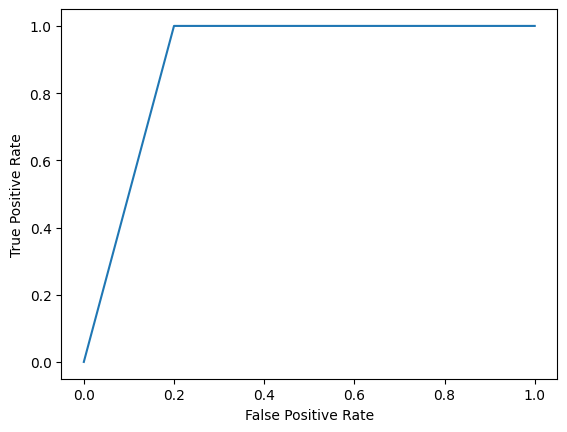

[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 1 11]]



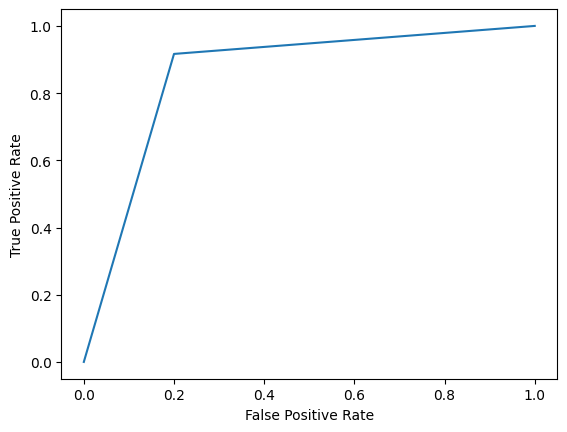

[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 0 12]]



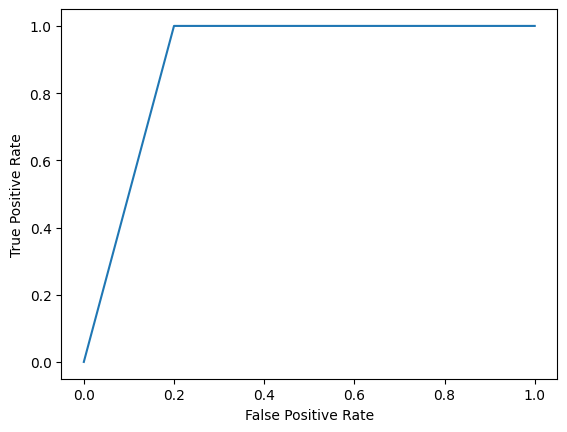

[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 0 12]]



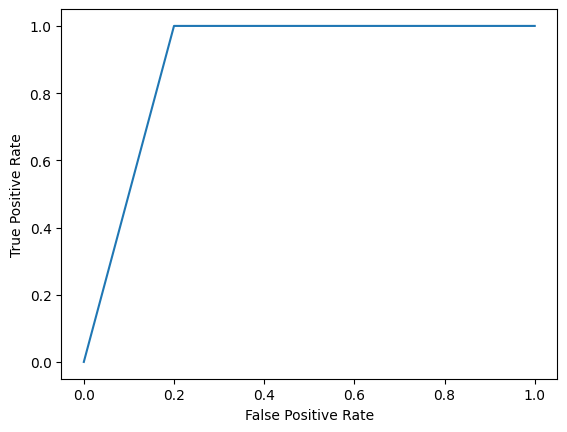

[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 0 12]]



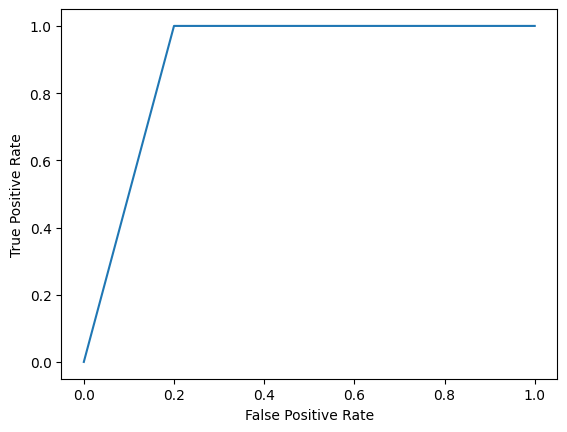

[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 0 12]]



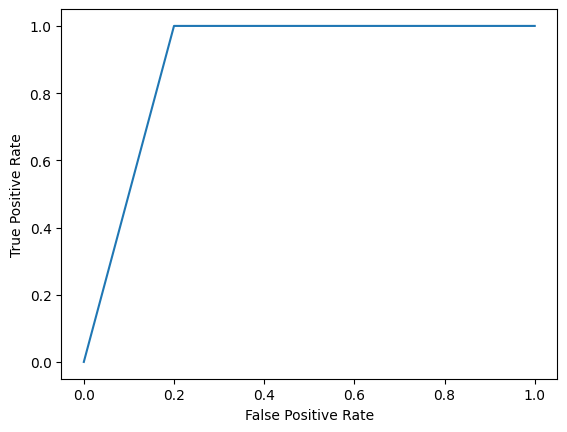

[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 0 12]]



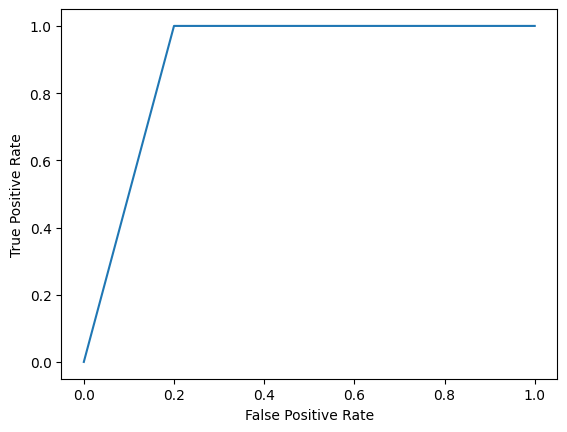

[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 0 12]]



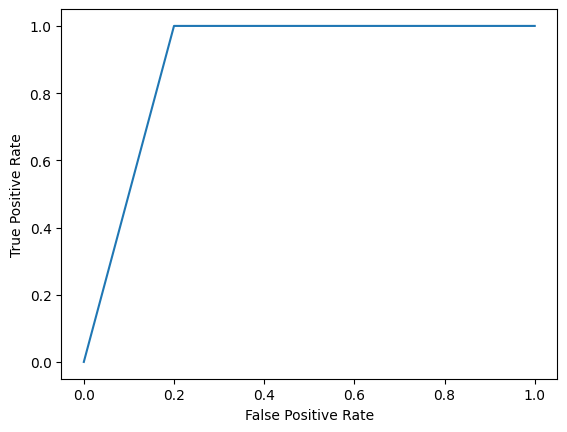

[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 0 12]]



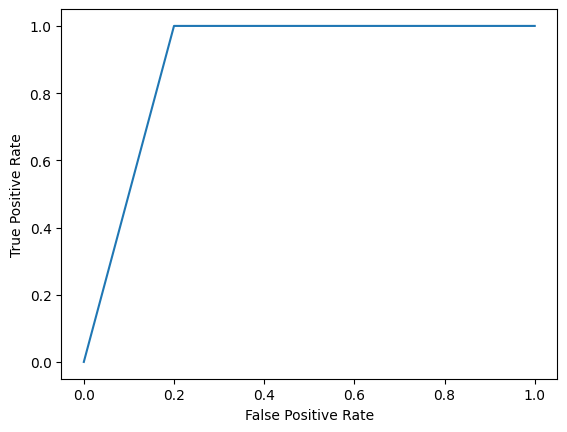

[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[12  3]
 [ 0 12]]



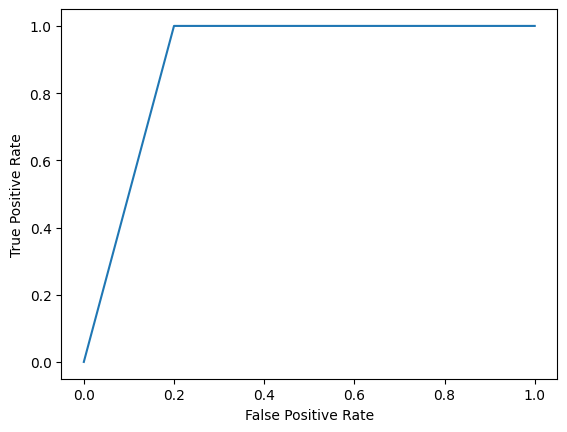

[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[15  0]
 [ 0 12]]



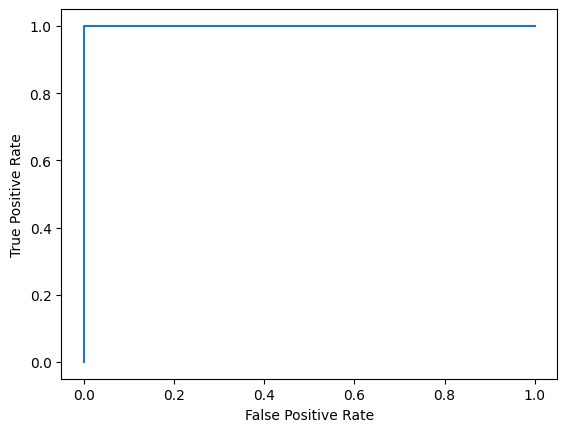

In [56]:

for trial in pred_phenotype_df.values:
    print(trial)
    print(np.array(new_test_y))
    print(test_blast_perc)
    cf_mat = confusion_matrix(new_test_y, trial)
    print('Confusion matrix')
    print(cf_mat)
    print('')
    plot_roc_curve(new_test_y, trial)
    plt.show()

In [34]:
'''Study resampling labels'''

resampled = []
y_labels_resampled = []
for res in results_list:
    for key, value in res.items():
        if key == 'resampled':
            resampled.append(value)
        if key == 'y_labels_resampled':
            y_labels_resampled.append(value)

print(len(resampled))
labels = []
for i in range(len(resampled)):
    for key, value in resampled[i].items():
        for sample in value:
            labels.append(sample[-1])

#print(len(labels))
y_labels = []
for i in range(len(y_labels_resampled)):
    for element in y_labels_resampled[i]:
        for lab in element:
            y_labels.append(lab)
#print(y_labels)
    
true_labels = []
for cells_labels in labels:
    cells_labels.sum()
    if cells_labels.sum() > 0:
        true_labels.append(1)
    else:
        true_labels.append(0)

    

#print(true_labels)

correct = 0
incorrect = 0
for true_l, y_l in zip(true_labels, y_labels):
    if true_l == y_l:
        correct += 1
    else:
        incorrect += 1
print(f'Correctly labeled: {correct}. Incorrect: {incorrect}')

cf_mat_resampled_labels = confusion_matrix(true_labels, y_labels)
print(cf_mat_resampled_labels)

10
Correctly labeled: 13500. Incorrect: 0
[[7500    0]
 [   0 6000]]
